# **Part 1: Visualization & Exploratory Data Analysis (EDA)**

### **Dataset Introduction**

In this project, we will work with the Palmer Penguins dataset, which contains measurements of penguins observed on islands near Antarctica.

Please download the dataset [penguins.csv](https://drive.google.com/file/d/1dv8A8v_sdf29p1At40S7KBslJPmBA3e9/view?usp=sharing) or from canvas.

### **Dataset Description**

Each row represents a penguin, and columns include:

- species – Penguin species
- island – Island where the penguin was found
- bill_length_mm – Bill length (mm)
- bill_depth_mm – Bill depth (mm)
- flipper_length_mm – Flipper length (mm)
- body_mass_g – Body mass (grams)
- sex – Sex of the penguin

Some values are missing, which makes this dataset ideal for practicing missing data handling.



Your task is to perform a comprehensive Exploratory Data Analysis (EDA) and visualization on the Palmer Penguins dataset. This project aims to deepen your understanding of data characteristics, relationships between variables, and effective data presentation using Python's data science libraries.

**Instructions:**

1.  **Load the Dataset:** Begin by loading the `penguins.csv` dataset into a pandas DataFrame.
2.  **Initial Data Inspection:** Perform an initial inspection to understand the dataset's structure. Display the first few rows, check data types and non-null values, and generate descriptive statistics.
3.  **Handle Missing Values:** Identify and address any missing values in the dataset. Clearly explain your chosen strategy for handling missing data (e.g., imputation, dropping rows/columns) and justify your decision.
4.  **Perform EDA and Visualization:** Conduct a thorough EDA, exploring distributions, relationships, and patterns within the data. You are required to use **at least three distinct types of visualizations** (e.g., histograms, scatter plots, box plots, bar charts). For each visualization:
    *   Justify your choice of plot type, explaining why it is suitable for the variables being analyzed.
    *   Clearly articulate what insights each visualization reveals about the data (e.g., distributions, correlations, outliers, group differences).
5.  **Summarize Key Findings:** Based on your EDA and visualizations, summarize the most important insights and observations about the Palmer Penguins dataset. Highlight any discovered patterns, trends, anomalies, or interesting relationships.
6.  **Final Task:** Present your complete EDA and visualization analysis, emphasizing key takeaways and interpretations of the observed data characteristics and relationships in a clear and concise manner.

1. Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("penguins.csv")

2. Initial Data Inspection

In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


3. Handle Missing Values

In [ ]:
df.isnull()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [ ]:
df[df['sex'].isnull()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


Missing 2 with all but species and island (3, 339)
Missing 10 for sex.

I think I'll drop the 2 that are missing 4/7 of the fields.



In [ ]:
df = df.dropna(thresh=4)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


I think we'll just work around selecting non-null entries for Sex when that' relevant, because the majority of those entries have all other data (dont want to drop the rows) and sex as a column has 334 entries (don't want to drop the column).

I'm going to plot body mass by penguin sex as a stacked histogram. There are null values, but also some "." that should be treated as null.

In [ ]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [ ]:
df_clean = df.drop(df[df["sex"] == "."].index)
df_clean = df_clean[df_clean["sex"].notnull()]
df_clean

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


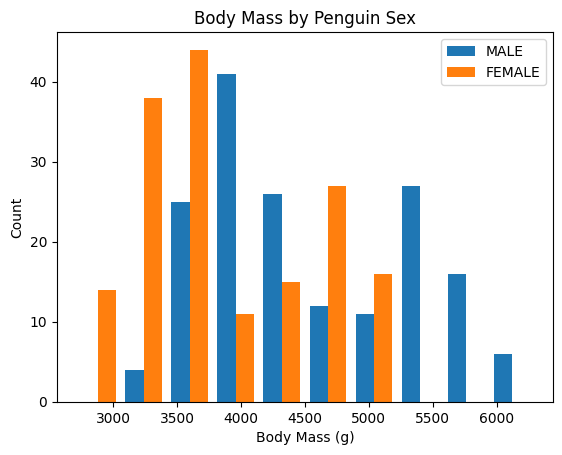

In [ ]:
plt_cats = df_clean["sex"].unique()
masses_m = df_clean[df_clean["sex"] == "MALE"]["body_mass_g"]
masses_f = df_clean[df_clean["sex"] == "FEMALE"]["body_mass_g"]

plt.hist([masses_m, masses_f])
plt.title("Body Mass by Penguin Sex")
plt.xlabel("Body Mass (g)")
plt.ylabel("Count")
plt.legend(plt_cats)

Each set of body masses seems to be bimodal. I want to now see if this relationship extends to another metric of size/shape (maybe filipper length?)

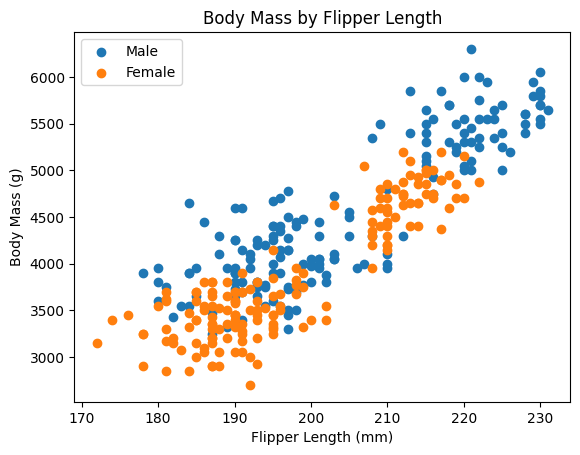

In [ ]:
masses_m = df_clean[df_clean["sex"] == "MALE"]["body_mass_g"]
flippers_m = df[df["sex"] == "MALE"]["flipper_length_mm"]

masses_f = df_clean[df_clean["sex"] == "FEMALE"]["body_mass_g"]
flippers_f = df[df["sex"] == "FEMALE"]["flipper_length_mm"]

plt.scatter(flippers_m, masses_m, label="Male")
plt.scatter(flippers_f, masses_f, label="Female")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Body Mass by Flipper Length")
plt.legend()



Flipper length seems to correlate fairly positively with body mass. I'll check out the correlation of the numeric variables.



In [ ]:
df_clean.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


Indeed, flipper length correlates strongly with body mass. Interestingly, bill length doesn't correlate as storngly, and bill depth has a negative correlation with body mass.

In the scatterplot, there are two clusters within each sex. I'd guess this is related to the remaining variables: island or species. I think I'll look at body weight by island, species, as well as male/female. I'll use a boxplot to get an idea of the center and spread for each category.

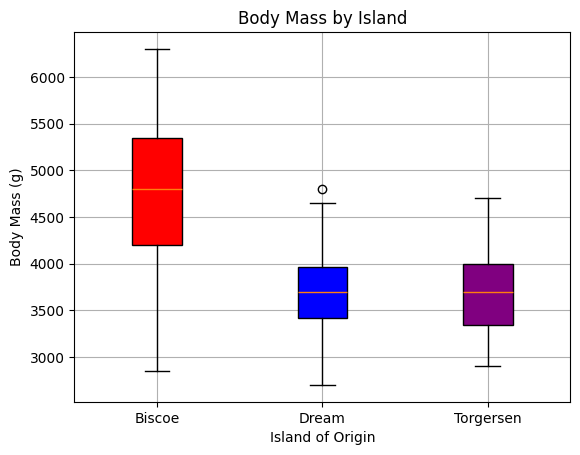

In [ ]:
islands = df_clean.groupby("island")

island_groups = []
island_names = []

for name, island in islands:
  body_masses = island["body_mass_g"]
  island_groups.append(body_masses)
  island_names.append(name)

bplot = plt.boxplot(island_groups,  patch_artist=True, tick_labels=island_names)
plt.xlabel("Island of Origin")
plt.ylabel("Body Mass (g)")
plt.title("Body Mass by Island")
plt.grid()

colors = ['red', 'blue', 'purple']

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

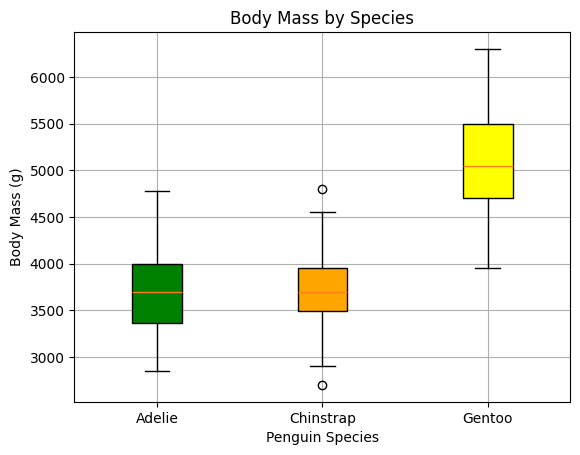

In [ ]:
species = df_clean.groupby("species")

species_groups = []
species_names = []

for name, island in islands:
  body_masses = island["body_mass_g"]
  species_groups.append(body_masses)
  species_names.append(name)

bplot = plt.boxplot(island_groups,  patch_artist=True, tick_labels=island_names)
plt.xlabel("Penguin Species")
plt.ylabel("Body Mass (g)")
plt.title("Body Mass by Species")
plt.grid()

colors = ['green', 'orange', 'yellow']

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

It looks like in general, there is one group for both island and species that is signifacantly bigger (in terms of body mass, although the scatterplot shows correlation between body mass and flipper length).

I want to know whether those two peaks overlap with eachother. I think I'm going to look at species counts by island.



In [ ]:
groups = df_clean.groupby(["island", "species"])[["island", "species"]].value_counts()
groups

island     species  
Biscoe     Adelie        44
           Gentoo       119
Dream      Adelie        55
           Chinstrap     68
Torgersen  Adelie        47
Name: count, dtype: int64

Gentoo are only on Biscoe. Now I want to see if we exclude the Gentoo, if there is still any noticable size difference from the island itself.

In [ ]:
df_nogentoo = df_clean[df_clean["species"] != "Gentoo"]
groups_nogentoo = df_nogentoo.groupby(["island", "species"])[["island", "species"]].value_counts()
groups_nogentoo

island     species  
Biscoe     Adelie       44
Dream      Adelie       55
           Chinstrap    68
Torgersen  Adelie       47
Name: count, dtype: int64

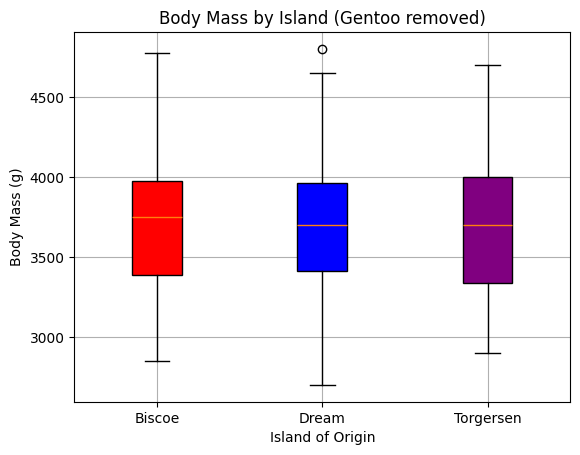

In [ ]:
islands = df_nogentoo.groupby("island")

island_groups = []
island_names = []

for name, island in islands:
  body_masses = island["body_mass_g"]
  island_groups.append(body_masses)
  island_names.append(name)

bplot = plt.boxplot(island_groups,  patch_artist=True, tick_labels=island_names)
plt.xlabel("Island of Origin")
plt.ylabel("Body Mass (g)")
plt.title("Body Mass by Island (Gentoo removed)")
plt.grid()

colors = ['red', 'blue', 'purple']

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

Without the Gentoo, the island seems to have little impact on Body Mass. So the second peak is likely a result of that species specifically.

Now I'm wondering how much the species impacts weight vs how much sex does for the whole sample. I'll put them head to head in a bar chart, measuring the mean of Gentoo vs non Gentoo by gender.

Text(0.5, 1.0, 'Body Mass of Gentoo vs Non-Gentoo')

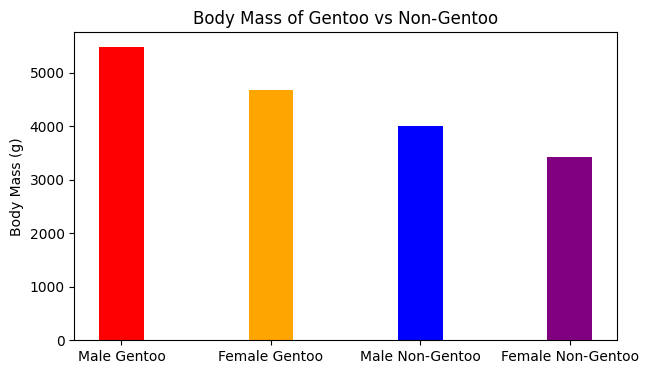

In [ ]:
mgentoo = df_clean[(df_clean["species"] == "Gentoo") & (df_clean["sex"] == "MALE")]["body_mass_g"].mean()
fgentoo = df_clean[(df_clean["species"] == "Gentoo") & (df_clean["sex"] == "FEMALE")]["body_mass_g"].mean()
mnot= df_clean[(df_clean["species"] != "Gentoo") & (df_clean["sex"] == "MALE")]["body_mass_g"].mean()
fnot= df_clean[(df_clean["species"] != "Gentoo") & (df_clean["sex"] == "FEMALE")]["body_mass_g"].mean()

plt.figure(figsize=(7, 4))
bargraph = plt.bar(["Male Gentoo", "Female Gentoo"],
 [mgentoo, fgentoo], color=["red","orange"], width=0.3)

bargraph = plt.bar(["Male Non-Gentoo", "Female Non-Gentoo"],
 [mnot,fnot], color=[ "blue", "purple"], width=0.3)

plt.ylabel("Body Mass (g)")
plt.title("Body Mass of Gentoo vs Non-Gentoo")


Looks like the species has a more prominent in predicting body mass than gender is.

In this exploration, I found that:


- The male penguins in the sample have a slightly higher average body mass and flipper length.
- Body weight and flipper length are strongly positively correlated, but beak length/depth aren't as strong (and depth is negatively correlated).
- The Gentoo have much higher masses, creating a prominent bimodal curve in the histogram and bar chart of body mass.
- The mean mass being very different per island was a result of the species difference, and not something specific about the island.

